In [1]:
import numpy as np
import h5py as h5

import astropy.units as u
import astropy.constants as C

In [2]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.cm import ScalarMappable

plt.rcParams["figure.figsize"] = (18, 3.5)
plt.rcParams["font.size"] = 10
plt.rcParams["legend.fontsize"] = 10
plt.rcParams["legend.frameon"] = False
plt.rcParams["font.family"] = "STIXGeneral"
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["xtick.major.size"] = 2
plt.rcParams["xtick.minor.size"] = 1
plt.rcParams["ytick.major.size"] = 2
plt.rcParams["ytick.minor.size"] = 1
plt.rcParams["xtick.major.width"] = 0.75
plt.rcParams["xtick.minor.width"] = 0.5
plt.rcParams["ytick.major.width"] = 0.75
plt.rcParams["ytick.minor.width"] = 0.5

In [3]:
unit_mass = 1.989e43  # in g
unit_length = 3.085678e24  # in cm
unit_velocity = 1.0e5  # in cm/s
little_h = 0.677

In [4]:
GAMMA = 5 / 3
X = 0.76
MU = 4 / (1 + 3 * X)

In [5]:
parent_dir = "/home/bsreedhar/scratch/HIMALAYA/testing/diff_SNe/"

sim_names = ["main", "main_fth",  "diff_SNe"]
d_names = ["main", "main_fth",  "SNe"]

In [6]:
snaps = [10, 16, 20, 25, 35]

In [7]:
def read_sim_data(
    sim_dir,
    snap=122,
):
    with h5.File(sim_dir + f"/data/snapshot_{snap:03d}.hdf5", "r") as hf:
        densities = hf["PartType0/Density"].astype(np.float64)[()]
        internal_energies = hf["PartType0/InternalEnergy"].astype(np.float64)[()]
        redshift = np.float64(hf["Header"].attrs["Redshift"])
        a_ = np.float64(hf["Header"].attrs["Time"])
    densities = (
        densities * unit_mass * little_h**-1 / ((a_ * unit_length) ** 3 * little_h**-3)
    )  # in g/cm^3
    
    internal_energies = internal_energies * unit_velocity**2  # in cm^2/s^2
    return redshift, densities, internal_energies

In [8]:
def make_phase_diagram(densities, internal_energies):
    dens = densities * (u.g / u.cm**3)  # cgs
    intE = internal_energies * (u.erg / u.g)  # cgs

    temp = (intE * (GAMMA - 1) * MU * C.m_p / C.k_B).to(u.K)

    ndens = (dens / (MU * C.m_p)).to(u.cm**-3)
    
    return ndens.value, temp.value

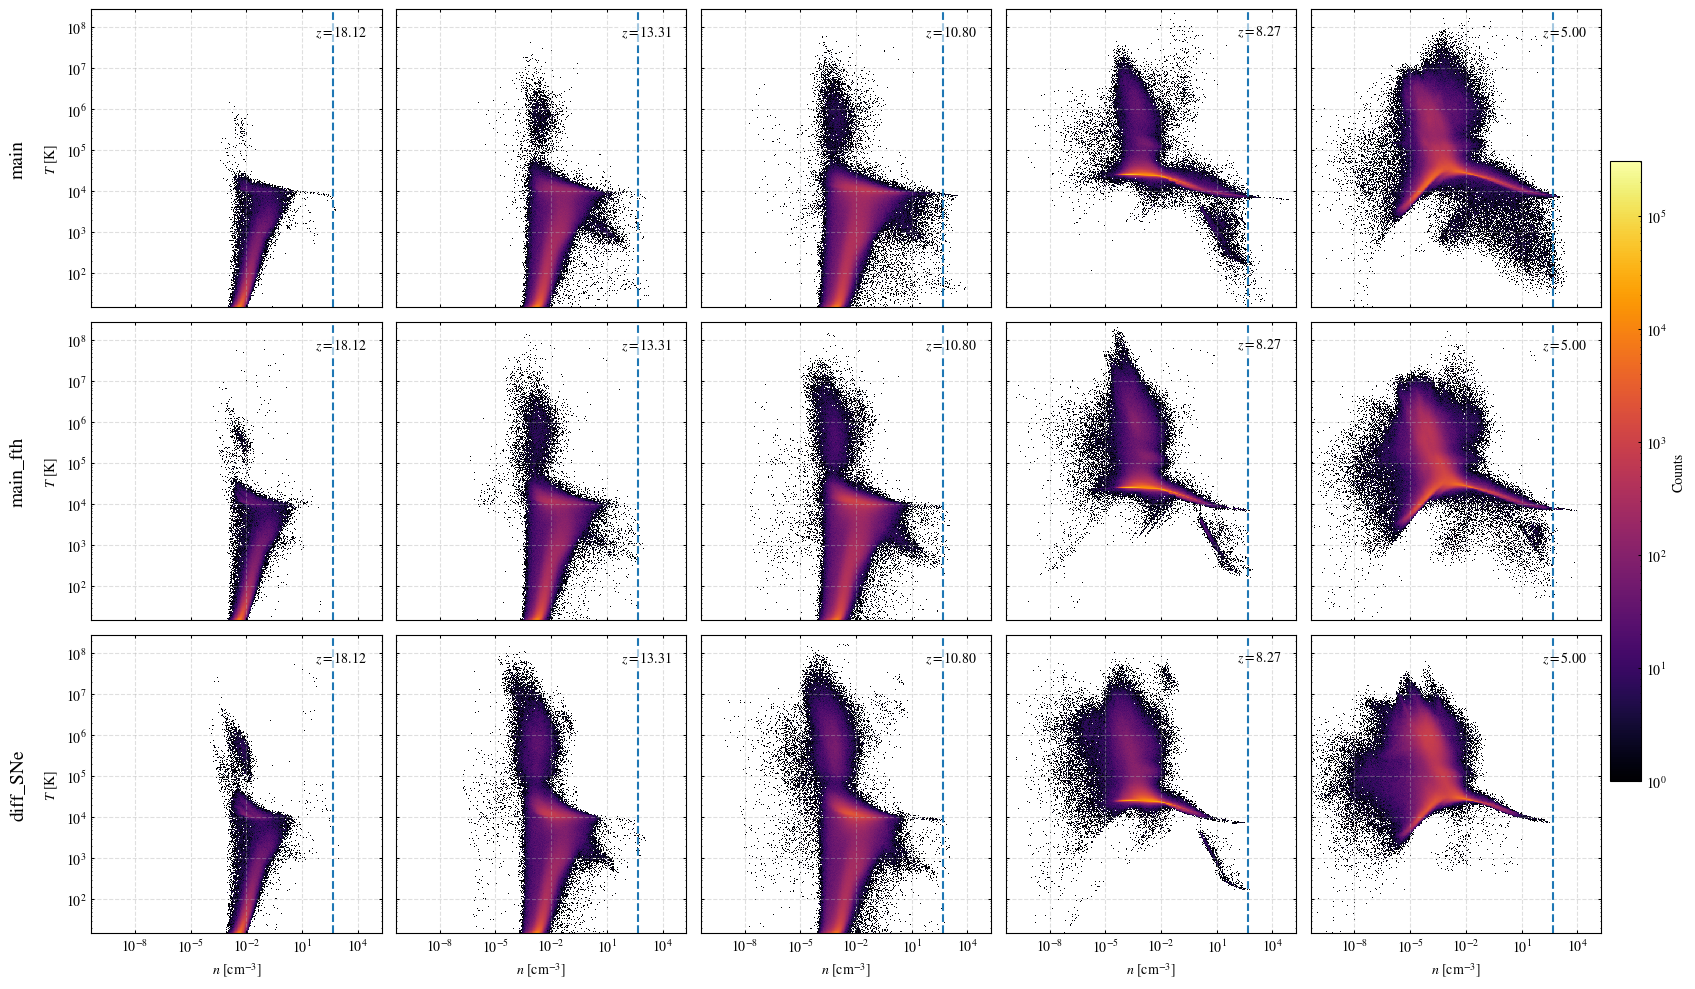

In [11]:
# --------------------------------------------------
# First pass: read ALL simulations
# --------------------------------------------------

phase_data = {}
all_raw = []

for sim_name in sim_names:

    sim_dir = parent_dir + "/" + sim_name
    phase_data[sim_name] = []

    for snap in snaps:

        redshift, densities, internal_energies = read_sim_data(
            sim_dir=sim_dir,
            snap=snap,
        )

        ndens, temp = make_phase_diagram(
            densities,
            internal_energies,
        )

        mask = (
            np.isfinite(ndens)
            & np.isfinite(temp)
            & (ndens > 0)
            & (temp > 0)
        )

        ndens = ndens[mask]
        temp = temp[mask]

        phase_data[sim_name].append(
            {
                "redshift": redshift,
                "ndens": ndens,
                "temp": temp,
            }
        )

        all_raw.append((ndens, temp))


# --------------------------------------------------
# Use common bins for ALL simulations/snapshots
# --------------------------------------------------

all_ndens = np.concatenate([x[0] for x in all_raw])
all_temp  = np.concatenate([x[1] for x in all_raw])

x_bin = np.logspace(
    np.log10(all_ndens.min()),
    np.log10(all_ndens.max()),
    500,
)

y_bin = np.logspace(
    np.log10(all_temp.min()),
    np.log10(all_temp.max()),
    500,
)


# --------------------------------------------------
# Determine global colour normalization
# --------------------------------------------------

all_histograms = []

for sim_name in sim_names:
    for data in phase_data[sim_name]:

        H, _, _ = np.histogram2d(
            data["ndens"],
            data["temp"],
            bins=[x_bin, y_bin],
        )

        all_histograms.append(H)

all_vals = np.concatenate(
    [H.ravel() for H in all_histograms]
)

nonzero = all_vals[all_vals > 0]

if len(nonzero) == 0:
    vmin = 1
    vmax = 10
else:
    vmin = nonzero.min()
    vmax = nonzero.max()


# --------------------------------------------------
# Figure setup
# --------------------------------------------------

fig, axs_ = plt.subplots(
    len(sim_names),
    len(snaps),
    figsize=(4 * len(snaps), 4 * len(sim_names)),
    sharex=True,
    sharey=True,
)

if len(sim_names) == 1 and len(snaps) == 1:
    axs_ = np.array([[axs_]])
elif len(sim_names) == 1:
    axs_ = axs_[None, :]
elif len(snaps) == 1:
    axs_ = axs_[:, None]


# --------------------------------------------------
# Plot
# --------------------------------------------------

for i_sim, sim_name in enumerate(sim_names):

    for j_snap, snap in enumerate(snaps):

        ax = axs_[i_sim, j_snap]
        data = phase_data[sim_name][j_snap]

        pcm = ax.hist2d(
            data["ndens"],
            data["temp"],
            bins=[x_bin, y_bin],
            norm=LogNorm(
                vmin=vmin,
                vmax=vmax,
            ),
            cmap="inferno",
        )

        pcm[3].set_rasterized(True)

        ax.set_xscale("log")
        ax.set_yscale("log")

        ax.grid(
            True,
            ls="--",
            alpha=0.4,
        )

        ax.text(
            0.95,
            0.95,
            rf"$z={data['redshift']:.2f}$",
            transform=ax.transAxes,
            ha="right",
            va="top",
            fontsize=10,
            bbox=dict(
                facecolor="white",
                edgecolor="none",
                alpha=0.6,
                pad=2,
            ),
        )

        if j_snap == 0:
            ax.set_ylabel(r"$T~[{\rm K}]$")

        if i_sim == len(sim_names) - 1:
            ax.set_xlabel(r"$n~[{\rm cm}^{-3}]$")

        ax.axvline(500, ls="--", lw=1.5)

# --------------------------------------------------
# Row labels
# --------------------------------------------------

for i_sim, sim_name in enumerate(sim_names):

    axs_[i_sim, 0].text(
        -0.25,
        0.5,
        sim_name,
        transform=axs_[i_sim, 0].transAxes,
        rotation=90,
        va="center",
        ha="center",
        fontsize=14,
    )


# --------------------------------------------------
# Shared colourbar
# --------------------------------------------------

sm = ScalarMappable(
    norm=LogNorm(vmin=vmin, vmax=vmax),
    cmap="inferno",
)

sm.set_array([])

cbar = fig.colorbar(
    sm,
    ax=axs_,
    orientation="vertical",
    fraction=0.02,
    pad=0.04,
)

cbar.set_label("Counts")


fig.subplots_adjust(
    hspace=0.05,
    wspace=0.05,
    right=0.88,
)

plt.savefig(
    "/home/bsreedhar/plots_HIMALAYA/SNe_diff.pdf",
    dpi=300,
    bbox_inches="tight",
)

plt.show()
plt.close()